In [ ]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report
import pickle
from matplotlib import pyplot as plt

# =====================================================================
# 1. PREPARACIÓN DE LOS DATOS
# =====================================================================

In [ ]:
print("Cargando la base de datos de Malaria...")
df = pd.read_csv('Malaria Diseases dataset - .csv')

Cargando la base de datos de Malaria...


In [ ]:
# Binarizar textos
df['Sex'] = df['Sex'].map({'Male': 0, 'Female': 1})
categorias_originales = list(df['Result'].astype('category').cat.categories)
df['Result'] = df['Result'].astype('category').cat.codes
df.dropna(inplace=True)

In [ ]:
print("Categorías:", categorias_originales)  # ['negative', 'positive']

Categorías: ['negative', 'positive']


In [ ]:
Y = df['Result'].values
columnas = ["Sex", "Age", "Hemoglobin(Hb%)", "Total WBC count(/cumm)",
            "Neutrophils", "Lymphocytes", "Total Cir.Eosinophils",
            "HTC/PCV(%)", "MCH(pg)", "MCHC(g/dl)", "RDW-CV(%)", "Platelet Count"]
X = df[list(columnas)].values

# =====================================================================
# 2. MODELO 1: ÁRBOL DE DECISIÓN
# =====================================================================

In [ ]:
print("\n--- ENTRENANDO ÁRBOL DE DECISIÓN ---")
miarbol = tree.DecisionTreeClassifier(criterion="entropy")
miarbol = miarbol.fit(X, Y)


--- ENTRENANDO ÁRBOL DE DECISIÓN ---


In [ ]:
# Score sobre el 100% de los datos
print("Precisión del Árbol:", 100 * miarbol.score(X, Y), "%")

Precisión del Árbol: 100.0 %


In [ ]:
# Predicción sobre el 100% de los datos
Ypredecido = miarbol.predict(X)


Matriz de Confusión - ÁRBOL DE DECISIÓN:
 [[1122    0]
 [   0 1068]]
Métricas:
               precision    recall  f1-score   support

    negative       1.00      1.00      1.00      1122
    positive       1.00      1.00      1.00      1068

    accuracy                           1.00      2190
   macro avg       1.00      1.00      1.00      2190
weighted avg       1.00      1.00      1.00      2190



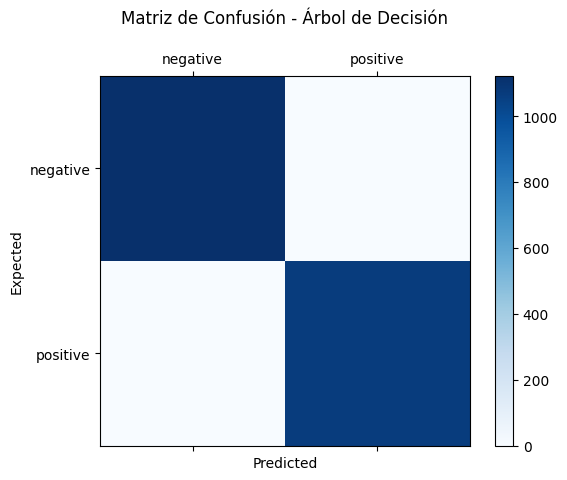

In [ ]:
# =====================================================================
# 3. MATRIZ DE CONFUSIÓN Y REPORTES
# =====================================================================
conf_mat = confusion_matrix(y_true=Y, y_pred=Ypredecido)
print('\nMatriz de Confusión - ÁRBOL DE DECISIÓN:\n', conf_mat)
print('Métricas:\n', classification_report(Y, Ypredecido,
      target_names=categorias_originales))

# Gráfico
labels = categorias_originales
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.title('Matriz de Confusión - Árbol de Decisión\n')
plt.show()

In [ ]:
with open('malaria_tree_lab.pkl', 'wb') as outfile:
    pickle.dump(miarbol, outfile)

print("\n✅ Árbol guardado correctamente como 'malaria_tree_lab.pkl'")


✅ Árbol guardado correctamente como 'malaria_tree_lab.pkl'


In [ ]:
with open("malaria_lab.dot", 'w') as f:
    f = tree.export_graphviz(miarbol, out_file=f, feature_names=columnas)

!dot -Tpng ./malaria_lab.dot -o ./malaria_lab.png

from IPython.display import Image
Image("malaria_lab.png")